In [1]:
import torch
import timm
import os
import random
import numpy as np

IS_KAGGLE = os.path.exists("/kaggle")

if IS_KAGGLE:
    BASE_DIR = "/kaggle/working"
else:
    BASE_DIR = "."

RUNS_DIR    = os.path.join(BASE_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)

def save_siamnet_weights(model, run_name: str) -> str:
    """Full SiamNet state_dict (encoder + head) under RUNS_DIR."""
    path = os.path.join(RUNS_DIR, f"{run_name}_state.pt")
    torch.save(model.state_dict(), path)
    return path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

g = torch.Generator()
g.manual_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# Augs

In [ ]:
import torchvision.transforms as transforms
import numpy as np
import random
import string
import io
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from torchvision.transforms import functional


class RandomCompose(object):
    def __init__(self, transforms, p=0.5):
        self.p = p
        self.transforms = transforms

    def __call__(self, img):
        for t in self.transforms:
            if random.random() < self.p:
                img = t(img)
        return img


# === Геометрические ===

class Crop(object):
    def __init__(self):
        pass

    def __call__(self, img):
        size = random.uniform(1, 10)
        w, h = img.size
        max_left = max(0, int(w * size / 100))
        max_top = max(0, int(h * size / 100))
        left = random.randint(0, max_left)
        top = random.randint(0, max_top)
        min_width = int(w * (1 - size / 100)) - left
        max_width = w - left - 1
        if min_width > max_width:
            min_width = max_width
        width = random.randint(max(1, min_width), max(1, max_width))
        min_height = int(h * (1 - size / 100)) - top
        max_height = h - top - 1
        if min_height > max_height:
            min_height = max_height
        height = random.randint(max(1, min_height), max(1, max_height))
        img = functional.crop(img, top=top, left=left, height=height, width=width)
        return img


class Scale(object):
    def __init__(self):
        pass

    def __call__(self, img):
        if random.random() > 0.2:
            scale = random.uniform(0.3, 2)
            w, h = img.size
            h = int(h * scale)
            w = int(w * scale)
            img = functional.resize(img, size=(h, w))
        else:
            scale_h = random.uniform(0.3, 2)
            scale_w = random.uniform(0.3, 2)
            w, h = img.size
            h = int(h * scale_h)
            w = int(w * scale_w)
            img = functional.resize(img, size=(h, w))
        return img


class RandomRotation90(object):
    def __call__(self, img):
        angle = random.choice([90, 180, 270])
        img = functional.rotate(img, angle, expand=True)
        return img


# === Пиксельные ===

class GaussianNoise(object):
    def __init__(self, std_range=(0.01, 0.05)):
        self.std_range = std_range

    def __call__(self, img):
        img_np = np.array(img).astype(np.float32) / 255.0
        std = random.uniform(*self.std_range)
        noise = np.random.normal(0, std, img_np.shape).astype(np.float32)
        img_np = np.clip(img_np + noise, 0, 1)
        return Image.fromarray((img_np * 255).astype(np.uint8))


class JPEGCompression(object):
    def __init__(self, quality_range=(10, 50)):
        self.quality_range = quality_range

    def __call__(self, img):
        quality = random.randint(*self.quality_range)
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert('RGB')


# === Overlay ===

class RandomWatermark(object):
    def __init__(self, alpha_range=(0.1, 0.4)):
        self.alpha_range = alpha_range

    def __call__(self, img):
        overlay = Image.new('RGBA', img.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        text = ''.join(random.choices(string.ascii_uppercase, k=random.randint(2, 5)))
        font_size = max(8, img.size[0] // 3)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", font_size)
        except (OSError, IOError):
            font = ImageFont.load_default()
        x = random.randint(0, max(0, img.size[0] - font_size))
        y = random.randint(0, max(0, img.size[1] - font_size))
        alpha = int(255 * random.uniform(*self.alpha_range))
        color = (
            random.randint(100, 255),
            random.randint(100, 255),
            random.randint(100, 255),
            alpha
        )
        draw.text((x, y), text, fill=color, font=font)
        return Image.alpha_composite(img.convert('RGBA'), overlay).convert('RGB')


def get_augmentations(aug=False):
    # D4
    d4_augs = [
        RandomRotation90(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
    ]
    # Геометрические
    geometric_augs = [
        Crop(),
        Scale(),
    ]
    # Пиксельные
    pixel_augs = [
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        GaussianNoise(std_range=(0.01, 0.05)),
        JPEGCompression(quality_range=(10, 50)),
    ]
    # Overlay
    overlay_augs = [
        RandomWatermark(alpha_range=(0.1, 0.4)),
        transforms.RandomErasing(p=1.0, scale=(0.02, 0.15)),  # применяется к тензору, обработаем отдельно
    ]

    all_augs = d4_augs + geometric_augs + pixel_augs + [RandomWatermark(alpha_range=(0.1, 0.4))]

    if aug:
        return transforms.Compose([
            RandomCompose(all_augs, p=0.3),
            transforms.Resize((32, 32)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((32, 32)),
        ])

# Models

In [ ]:
from timm.models.vision_transformer import VisionTransformer
import torch.nn as nn

class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = VisionTransformer(
            img_size=32,           # Стандартный размер входного изображения для предобученных весов
            patch_size=4,          # Размер патча (ViT-.../16)
            in_chans=3,
            num_classes = 0,
            embed_dim=192,          # Ключевой параметр: скрытая размерность для Tiny
            depth=12,               # Количество слоёв трансформера
            num_heads=3,            # Количество голов внимания (192 / 64 = 3)
            mlp_ratio=4.0,          # Соотношение размера MLP к embed_dim (192 * 4 = 768)
            class_token=True,       # Использовать классификационный токен
            global_pool='token',    # Использовать class token для классификации
        )
        self.feature_dim = 192

    def forward(self, x):
        return self.backbone(x)


In [4]:
!git clone -q https://github.com/davnords/octic-vits.git

import sys
sys.path.insert(0, "octic-vits")

In [5]:
from octic_vits import OcticVisionTransformer
import os
import torch.nn as nn

class OcticViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_dim = 192

        self.backbone = OcticVisionTransformer(
            img_size=32,
            patch_size=4,
            embed_dim=192,
            depth=12,
            num_heads=3,
            invariant=True,
            num_classes=0,
        )

    def forward(self, x):
        out = self.backbone(x)
        return out


In [ ]:
import sys
import os
import torch.nn as nn

_harm_paths = [
    os.path.join(BASE_DIR, "newcode"),
    BASE_DIR,
    os.path.join(os.getcwd(), "newcode"),
    os.getcwd(),
]
for _p in _harm_paths:
    if _p and os.path.isfile(os.path.join(_p, "harmformer_encoder.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        break

from harmformer_encoder import HarmformerEncoder


class HarmformerViTEncoder(nn.Module):
    """Tiny Harmformer; same embedding dim as ViT/Octic (192)."""

    def __init__(self):
        super().__init__()
        self.backbone = HarmformerEncoder(
            img_size=32,
            stem_channels=[16, 32],
            encoder_dim=64,       # feature_dim = 3 * 64 = 192
            encoder_depth=4,
            num_heads=4,
        )
        self.feature_dim = self.backbone.feature_dim

    def forward(self, x):
        return self.backbone(x)


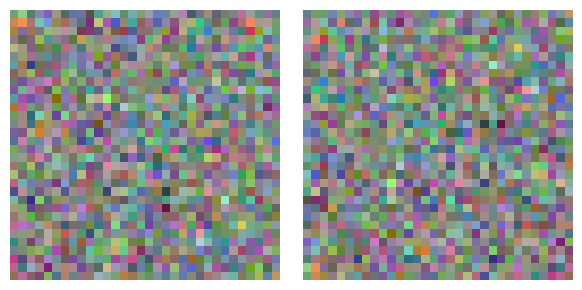

True


In [6]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

enc = ViTEncoder().to(device)
enc.eval()

enc_oc = OcticViTEncoder().to(device)
enc_oc.eval()

enc_hf = HarmformerViTEncoder().to(device)
enc_hf.eval()

img = torch.randn(1, 3, 32, 32).to(device)
angle = 90

img_rot = functional.rotate(
    img,
    angle,
    expand=True)

img_rot32 = F.interpolate(img_rot, size=(32, 32), mode="bilinear", align_corners=False)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, im in zip(axes, [img, img_rot]):
    img_np = im.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    ax.imshow(img_np)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("OcticViT allclose(img, img_rot):", torch.allclose(enc_oc(img), enc_oc(img_rot)))
print("Harmformer cos(emb, emb_rot32):", F.cosine_similarity(enc_hf(img), enc_hf(img_rot32), dim=-1).item())

In [7]:
class HeadModel(nn.Module):
    """Advanced head that accepts pre-computed difference AND product embeddings.
    
    This architecture is designed to work with pre-computed difference vectors AND element-wise products.
    The inputs should already be in the format:
    - diff_embeddings: [|emb1 - emb2|] for all pairs
    - product_embeddings: [emb1 * emb2] for all pairs
    """
    
    def __init__(self, feature_dim, dropout_rate=0.1):
        """
        Args:
            feature_dim (int): Dimension of input feature vectors
            dropout_rate (float): Dropout probability. Defaults to 0.1.
        """
        super().__init__()
        
        self.diff_pathway = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.product_pathway = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(2 * feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(feature_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, diff_embeddings, product_embeddings):
        """
        Forward pass with pre-computed difference and product features.
        
        Args:
            diff_embeddings: Tensor of shape [batch_size, feature_dim] 
                representing pre-computed |embedding1 - embedding2|
            product_embeddings: Tensor of shape [batch_size, feature_dim]
                representing pre-computed element-wise product of embeddings
                
        Returns:
            Tensor of shape [batch_size, 1] with similarity probabilities (after sigmoid)
        """
        diff_features = self.diff_pathway(diff_embeddings)
        product_features = self.product_pathway(product_embeddings)
        
        combined = torch.cat([diff_features, product_features], dim=1)
        return self.fusion(combined)


In [8]:
class SiamNet(nn.Module):
    def __init__(self, encoder):
        super(SiamNet, self).__init__()
        self.encoder = encoder

        self.head = HeadModel(self.encoder.feature_dim)

    def forward(self, batch1: torch.Tensor, batch2: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the siamese network.

        Args:
            batch1: First batch of images [batch_size, channels, height, width]
            batch2: Second batch of images [batch_size, channels, height, width]

        Returns:
            torch.Tensor: Similarity matrix [batch_size1, batch_size2]
        """
        emb1 = self.encoder(batch1)
        emb2 = self.encoder(batch2)

        batch_size1, batch_size2 = emb1.size(0), emb2.size(0)
        emb1_expanded = emb1.unsqueeze(1).expand(-1, batch_size2, -1)
        emb2_expanded = emb2.unsqueeze(0).expand(batch_size1, -1, -1)

        # Pre-compute the difference and product vectors
        diff_embeddings = torch.abs(emb1_expanded - emb2_expanded)
        product_embeddings = emb1_expanded * emb2_expanded
        
        # Reshape for head model
        diff_embeddings = diff_embeddings.view(-1, self.encoder.feature_dim)
        product_embeddings = product_embeddings.view(-1, self.encoder.feature_dim)

        # Pass pre-computed features to the head
        logits = self.head(diff_embeddings, product_embeddings)
            
        logits = logits.view(batch_size1, batch_size2)
        return logits


In [9]:
model = SiamNet(enc_oc)
model.to(device)
model.eval()
model(img, img_rot), model(img, img)

(tensor([[0.5174]], device='cuda:0', grad_fn=<ViewBackward0>),
 tensor([[0.5174]], device='cuda:0', grad_fn=<ViewBackward0>))

# Dataset

In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from PIL import Image

class CIFARDataset(Dataset):
    def __init__(self, train, aug=False):
        self.aug = aug
        self.augment = get_augmentations(aug)
        self.to_tensor = transforms.Compose([
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
        ])
        self.dataset = datasets.CIFAR10(
            root='./data',
            train=train,
            download=True,
            transform=None
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]         
        aug_img = self.augment(img) if self.aug else img
        return self.to_tensor(img), self.to_tensor(aug_img)

In [11]:
train_loader_no_aug = DataLoader(
    CIFARDataset(train=True, aug=False),
    batch_size=32, shuffle=True, num_workers=2,
    pin_memory=True, drop_last=True,
    worker_init_fn=seed_worker, generator=g,
)

train_loader_aug = DataLoader(
    CIFARDataset(train=True, aug=True),
    batch_size=32, shuffle=True, num_workers=2,
    pin_memory=True, drop_last=True,
    worker_init_fn=seed_worker, generator=g,
)

test_loader = DataLoader(
    CIFARDataset(train=False, aug=True),
    batch_size=32, shuffle=True, num_workers=2,
    pin_memory=True, drop_last=True,
    worker_init_fn=seed_worker, generator=g,
)

100%|██████████| 170M/170M [00:02<00:00, 79.8MB/s]


# Regularizer

In [12]:
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=0.5):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        # label: 1 = same class, 0 = different class
        D = torch.norm(emb1 - emb2, p=2, dim=1)  # L2 норма
        pos = label * D ** 2
        neg = (1 - label) * torch.clamp(self.margin - D, min=0) ** 2
        return (pos + neg).mean()

# Train

In [13]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryAccuracy, BinaryF1Score, BinaryRecall,
    BinaryPrecision, BinarySpecificity
)
from tqdm import tqdm


def make_metrics(device):
    return MetricCollection({
        'accuracy':    BinaryAccuracy(),
        'f1':          BinaryF1Score(),
        'recall':      BinaryRecall(),
        'precision':   BinaryPrecision(),
        'specificity': BinarySpecificity(),
    }).to(device)


def train_model(model, train_loader, test_loader, optimizer, scheduler,
                num_epochs, device, regularizer=None, lam=0.05,
                log_dir='runs'):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'train_f1': [], 'val_f1': [],
        'train_recall': [], 'val_recall': [],
        'train_precision': [], 'val_precision': [],
        'train_fpr': [], 'val_fpr': [],
        'lr': [],
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_total = 0
        train_metrics = make_metrics(device)

        for batch1, batch2 in tqdm(train_loader, desc=f'Train {epoch+1}/{num_epochs}'):
            batch1, batch2 = batch1.to(device), batch2.to(device)
            batch_size = batch1.size(0)
            pairs_batch_size = batch_size ** 2

            optimizer.zero_grad()

            embs1 = model.encoder(batch1)
            embs2 = model.encoder(batch2)

            embs1_expanded = embs1.unsqueeze(1).expand(-1, batch_size, -1)
            embs2_expanded = embs2.unsqueeze(0).expand(batch_size, -1, -1)

            diff_embeddings = torch.abs(embs1_expanded - embs2_expanded).view(-1, model.encoder.feature_dim)
            product_embeddings = (embs1_expanded * embs2_expanded).view(-1, model.encoder.feature_dim)

            probabilities = model.head(diff_embeddings, product_embeddings).view(-1)

            labels = torch.eye(batch_size, device=device).view(-1)

            weight = torch.full_like(labels, 0.7)
            weight[labels == 1] = 0.3

            loss = torch.nn.functional.binary_cross_entropy(probabilities, labels, weight=weight)

            if regularizer is not None:
                embs1_all = embs1_expanded.reshape(-1, embs1.size(-1))
                embs2_all = embs2_expanded.reshape(-1, embs2.size(-1))
                contrastive_loss = regularizer(embs1_all, embs2_all, labels)
                total_loss = loss + lam * contrastive_loss
            else:
                total_loss = loss

            total_loss.backward()
            optimizer.step()

            train_loss += total_loss.item() * pairs_batch_size
            train_total += pairs_batch_size
            train_metrics.update(probabilities.detach(), labels.int())

        scheduler.step()
        tm = train_metrics.compute()
        train_metrics.reset()
        train_loss /= train_total
        train_fpr = 1 - float(tm['specificity'])

        model.eval()
        val_loss = 0.0
        val_total = 0
        val_metrics = make_metrics(device)

        with torch.no_grad():
            for batch1, batch2 in tqdm(test_loader, desc=f'Val {epoch+1}/{num_epochs}'):
                batch1, batch2 = batch1.to(device), batch2.to(device)
                batch_size = batch1.size(0)
                pairs_batch_size = batch_size ** 2

                embs1 = model.encoder(batch1)
                embs2 = model.encoder(batch2)

                embs1_expanded = embs1.unsqueeze(1).expand(-1, batch_size, -1)
                embs2_expanded = embs2.unsqueeze(0).expand(batch_size, -1, -1)

                diff_embeddings = torch.abs(embs1_expanded - embs2_expanded).view(-1, model.encoder.feature_dim)
                product_embeddings = (embs1_expanded * embs2_expanded).view(-1, model.encoder.feature_dim)

                probabilities = model.head(diff_embeddings, product_embeddings).view(-1)

                labels = torch.eye(batch_size, device=device).view(-1)

                weight = torch.full_like(labels, 0.1)
                weight[labels == 1] = 0.9

                loss = torch.nn.functional.binary_cross_entropy(probabilities, labels, weight=weight)

                if regularizer is not None:
                    embs1_all = embs1_expanded.reshape(-1, embs1.size(-1))
                    embs2_all = embs2_expanded.reshape(-1, embs2.size(-1))
                    contrastive_loss = regularizer(embs1_all, embs2_all, labels)
                    total_loss = loss + lam * contrastive_loss
                else:
                    total_loss = loss

                val_loss += total_loss.item() * pairs_batch_size
                val_total += pairs_batch_size
                val_metrics.update(probabilities, labels.int())

        vm = val_metrics.compute()
        val_metrics.reset()
        val_loss /= val_total
        val_fpr = 1 - float(vm['specificity'])

        current_lr = optimizer.param_groups[0]['lr']

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss:.4f}, '
              f'Train Acc: {tm["accuracy"]:.4f}, '
              f'Train F1: {tm["f1"]:.4f}, '
              f'Train Recall: {tm["recall"]:.4f}, '
              f'Train Prec: {tm["precision"]:.4f}, '
              f'Train FPR: {train_fpr:.4f}, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {vm["accuracy"]:.4f}, '
              f'Val F1: {vm["f1"]:.4f}, '
              f'Val Recall: {vm["recall"]:.4f}, '
              f'Val Prec: {vm["precision"]:.4f}, '
              f'Val FPR: {val_fpr:.4f}, '
              f'LR: {current_lr}')

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        for m in ('accuracy', 'f1', 'recall', 'precision'):
            history[f'train_{m}'].append(float(tm[m]))
            history[f'val_{m}'].append(float(vm[m]))
        history['train_fpr'].append(train_fpr)
        history['val_fpr'].append(val_fpr)
        history['lr'].append(current_lr)

    return history

In [14]:
all_histories = {}

# Train ViT

## without augs

In [15]:
model_vit_no_augs = SiamNet(ViTEncoder())
model_vit_no_augs.to(device)

optimizer = torch.optim.AdamW(model_vit_no_augs.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_vit_no_augs, train_loader_no_aug, test_loader,
    optimizer, scheduler, num_epochs=30,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['vit_no_augs'] = history
_p = save_siamnet_weights(model_vit_no_augs, "vit_no_augs")
print(f"Saved weights: {_p}")
del model_vit_no_augs
torch.cuda.empty_cache()

Val 1/30: 100%|██████████| 312/312 [00:07<00:00, 39.29it/s]


Epoch [1/30], Train Loss: 0.0013, Train Acc: 0.9993, Train F1: 0.9887, Train Recall: 0.9780, Train Prec: 0.9996, Train FPR: 0.0000, Val Loss: 1.1640, Val Acc: 0.9777, Val F1: 0.4447, Val Recall: 0.2860, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.001


Val 2/30: 100%|██████████| 312/312 [00:07<00:00, 39.24it/s]


Epoch [2/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 1.1144, Val Acc: 0.9778, Val F1: 0.4478, Val Recall: 0.2885, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.001


Val 3/30: 100%|██████████| 312/312 [00:07<00:00, 41.50it/s]


...

Epoch [28/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 2.1131, Val Acc: 0.9779, Val F1: 0.4515, Val Recall: 0.2916, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 29/30: 100%|██████████| 312/312 [00:07<00:00, 41.70it/s]


Epoch [29/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 2.1333, Val Acc: 0.9777, Val F1: 0.4435, Val Recall: 0.2850, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 30/30: 100%|██████████| 312/312 [00:07<00:00, 41.50it/s]


Epoch [30/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 2.0985, Val Acc: 0.9780, Val F1: 0.4566, Val Recall: 0.2959, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


## with augs

In [16]:
model_vit_augs = SiamNet(ViTEncoder())
model_vit_augs.to(device)

optimizer = torch.optim.AdamW(model_vit_augs.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_vit_augs, train_loader_aug, test_loader,
    optimizer, scheduler, num_epochs=30,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['vit_augs'] = history
_p = save_siamnet_weights(model_vit_augs, "vit_augs")
print(f"Saved weights: {_p}")
del model_vit_augs
torch.cuda.empty_cache()

Val 1/30: 100%|██████████| 312/312 [00:07<00:00, 41.46it/s]


Epoch [1/30], Train Loss: 0.0025, Train Acc: 0.9985, Train F1: 0.9754, Train Recall: 0.9548, Train Prec: 0.9970, Train FPR: 0.0001, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 0.9999, Val Recall: 1.0000, Val Prec: 0.9998, Val FPR: 0.0000, LR: 0.001


Val 2/30: 100%|██████████| 312/312 [00:07<00:00, 41.54it/s]


Epoch [2/30], Train Loss: 0.0002, Train Acc: 0.9999, Train F1: 0.9983, Train Recall: 0.9978, Train Prec: 0.9988, Train FPR: 0.0000, Val Loss: 0.0001, Val Acc: 1.0000, Val F1: 0.9993, Val Recall: 0.9999, Val Prec: 0.9988, Val FPR: 0.0000, LR: 0.001


Val 3/30: 100%|██████████| 312/312 [00:07<00:00, 41.54it/s]


...

Epoch [28/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 29/30: 100%|██████████| 312/312 [00:07<00:00, 41.56it/s]


Epoch [29/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 30/30: 100%|██████████| 312/312 [00:07<00:00, 41.58it/s]

Epoch [30/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


# Train OcticViT

## without augs

In [17]:
model_oct_no_aug = SiamNet(OcticViTEncoder())
model_oct_no_aug.to(device)

optimizer = torch.optim.AdamW(model_oct_no_aug.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_oct_no_aug, train_loader_no_aug, test_loader,
    optimizer, scheduler, num_epochs=30,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['octic_no_aug'] = history
_p = save_siamnet_weights(model_oct_no_aug, "octic_no_aug")
print(f"Saved weights: {_p}")
del model_oct_no_aug
torch.cuda.empty_cache()

Val 1/30: 100%|██████████| 312/312 [00:15<00:00, 20.05it/s]


Epoch [1/30], Train Loss: 0.0013, Train Acc: 0.9990, Train F1: 0.9842, Train Recall: 0.9837, Train Prec: 0.9847, Train FPR: 0.0005, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.001


Val 2/30: 100%|██████████| 312/312 [00:15<00:00, 20.12it/s]


Epoch [2/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.001


Val 3/30: 100%|██████████| 312/312 [00:15<00:00, 20.51it/s]


...

Epoch [28/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 29/30: 100%|██████████| 312/312 [00:15<00:00, 20.12it/s]


Epoch [29/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 30/30: 100%|██████████| 312/312 [00:15<00:00, 20.08it/s]

Epoch [30/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


## with augs

In [18]:
model_oct_aug = SiamNet(OcticViTEncoder())
model_oct_aug.to(device)

optimizer = torch.optim.AdamW(model_oct_aug.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_oct_aug, train_loader_aug, test_loader,
    optimizer, scheduler, num_epochs=30,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['octic_aug'] = history
_p = save_siamnet_weights(model_oct_aug, "octic_aug")
print(f"Saved weights: {_p}")
del model_oct_aug
torch.cuda.empty_cache()

Val 1/30: 100%|██████████| 312/312 [00:15<00:00, 19.95it/s]


Epoch [1/30], Train Loss: 0.0011, Train Acc: 0.9995, Train F1: 0.9915, Train Recall: 0.9835, Train Prec: 0.9997, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.001


Val 2/30: 100%|██████████| 312/312 [00:15<00:00, 19.95it/s]


Epoch [2/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.001


Val 3/30: 100%|██████████| 312/312 [00:15<00:00, 20.45it/s]


...

Epoch [28/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 29/30: 100%|██████████| 312/312 [00:15<00:00, 19.64it/s]


Epoch [29/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


Val 30/30: 100%|██████████| 312/312 [00:16<00:00, 19.07it/s]


Epoch [30/30], Train Loss: 0.0000, Train Acc: 1.0000, Train F1: 1.0000, Train Recall: 1.0000, Train Prec: 1.0000, Train FPR: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000, Val F1: 1.0000, Val Recall: 1.0000, Val Prec: 1.0000, Val FPR: 0.0000, LR: 0.00025


# Train Harmformer

## without augs

In [ ]:
model_he_no_aug = SiamNet(HarmformerViTEncoder())
model_he_no_aug.to(device)

optimizer = torch.optim.AdamW(model_he_no_aug.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_he_no_aug, train_loader_no_aug, test_loader,
    optimizer, scheduler, num_epochs=30,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['harmformer_no_aug'] = history
_p = save_siamnet_weights(model_he_no_aug, "harmformer_no_aug")
print(f"Saved weights: {_p}")
del model_he_no_aug
torch.cuda.empty_cache()

## with augs

In [ ]:
model_he_aug = SiamNet(HarmformerViTEncoder())
model_he_aug.to(device)

optimizer = torch.optim.AdamW(model_he_aug.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.5)

history = train_model(
    model_he_aug, train_loader_aug, test_loader,
    optimizer, scheduler, num_epochs=30,
    device=device, regularizer=ContrastiveLoss(margin=0.5)
)
all_histories['harmformer_aug'] = history
_p = save_siamnet_weights(model_he_aug, "harmformer_aug")
print(f"Saved weights: {_p}")
del model_he_aug
torch.cuda.empty_cache()

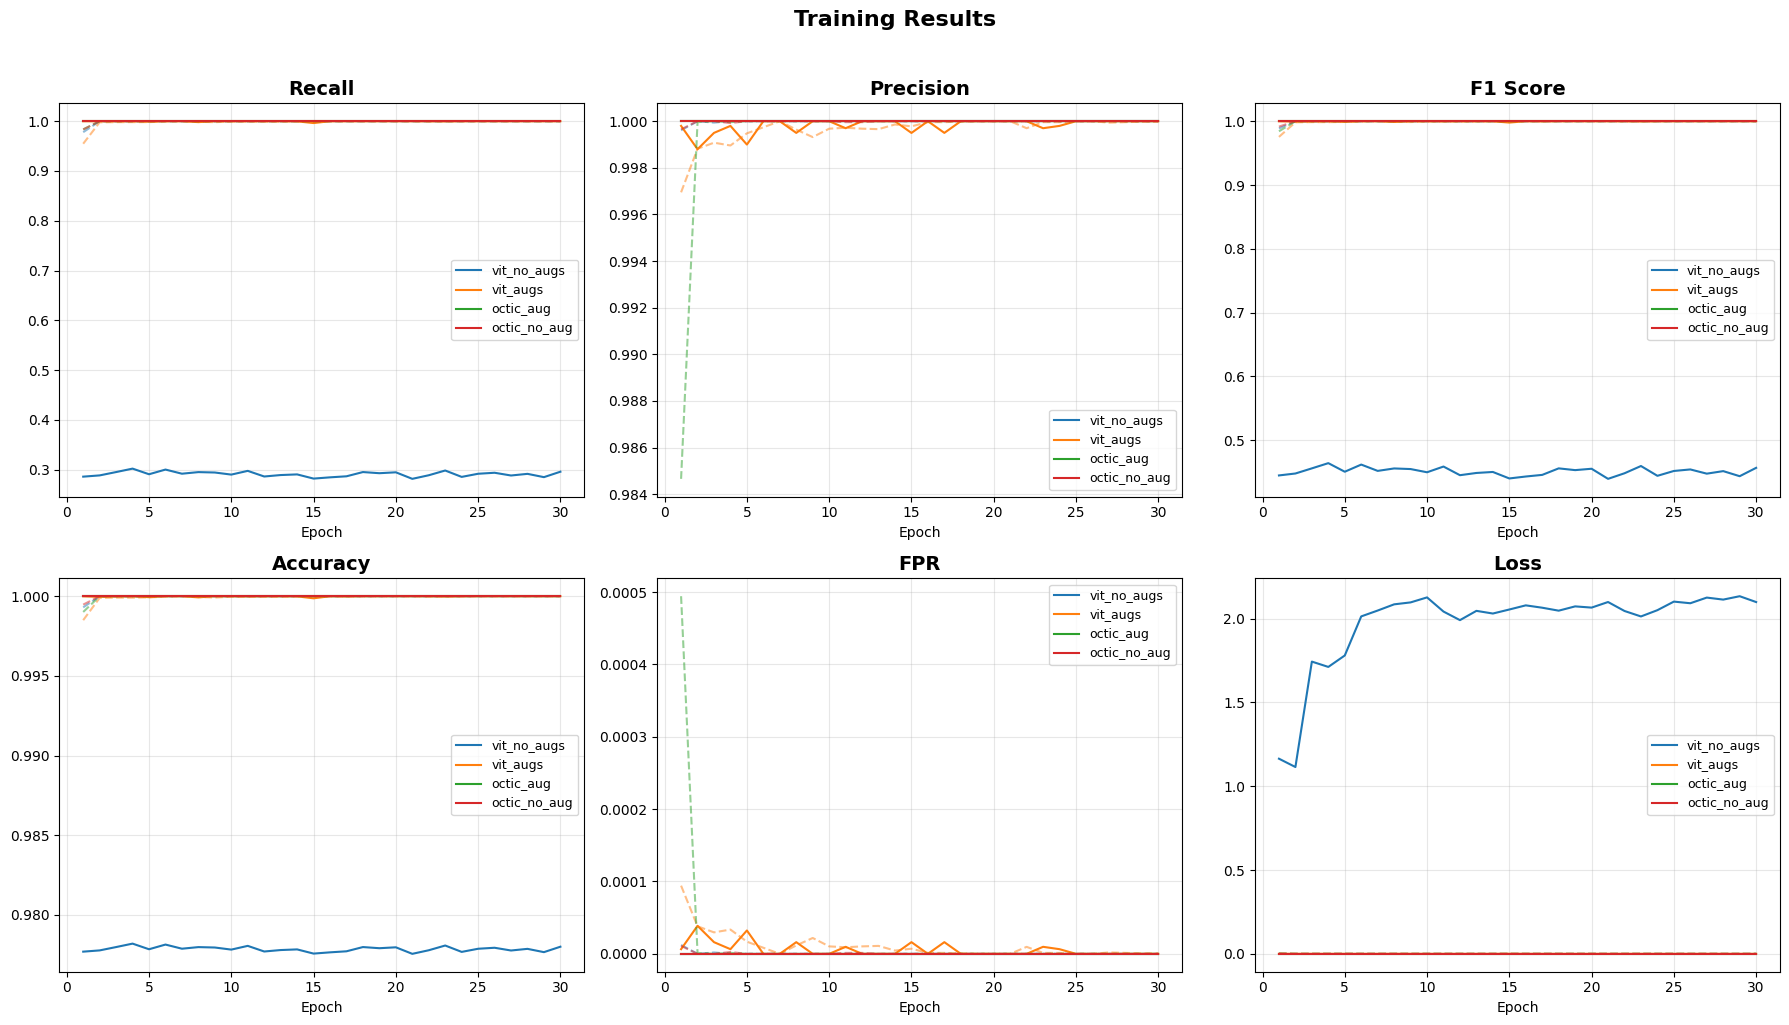

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [
    ('recall', 'Recall'),
    ('precision', 'Precision'),
    ('f1', 'F1 Score'),
    ('accuracy', 'Accuracy'),
    ('fpr', 'FPR'),
    ('loss', 'Loss'),
]
colors = plt.cm.tab10.colors

for ax, (key, title) in zip(axes.flat, metrics):
    for i, (label, h) in enumerate(all_histories.items()):
        epochs = range(1, len(h[f'train_{key}']) + 1)
        ax.plot(epochs, h[f'train_{key}'], color=colors[i], linestyle='--', alpha=0.5)
        ax.plot(epochs, h[f'val_{key}'], color=colors[i], linestyle='-', label=label)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Training Results', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(RUNS_DIR, 'metrics.png'), dpi=150, bbox_inches='tight')
plt.show()